# Import Libraries

In [17]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Saving model
import joblib

# Set visualization style
sns.set(style="whitegrid")


# Load Dataset

In [19]:

# Load the training dataset (contains demand values)
train = pd.read_csv(
    r"C:\Users\USER\Downloads\archive\foodDemand_train\train.csv"
)

# Load meal information (meal category, cuisine, etc.)
meal = pd.read_csv(
    r"C:\Users\USER\Downloads\archive\foodDemand_train\meal_info.csv"
)

# Load fulfillment center information (location, type, etc.)
center = pd.read_csv(
    r"C:\Users\USER\Downloads\archive\foodDemand_train\fulfilment_center_info.csv"
)

# Quick check: print dataset shapes
print("Train shape:", train.shape)
print("Meal shape:", meal.shape)
print("Center shape:", center.shape)

# Preview the first few rows of the training dataset
train.head()


Train shape: (456548, 9)
Meal shape: (51, 3)
Center shape: (77, 5)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


The dataset contains historical meal demand information from different distribution centers. 
It includes variables such as week number, meal type, pricing information, promotions, and the number of orders. 
This data will be used to train a machine learning model to predict future food demand.

# Merge Datasets

In [20]:

# Merge train with meal info
df = train.merge(meal, on="meal_id", how="left")

# Merge with center info
df = df.merge(center, on="center_id", how="left")

# Preview merged dataset
df.head()


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0


# Data Exploration

In [4]:
# Basic info
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 456548 entries, 0 to 456547
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   category               456548 non-null  object 
 10  cuisine                456548 non-null  object 
 11  city_code              456548 non-null  int64  
 12  region_code            456548 non-null  int64  
 13  center_type            456548 non-null  object 
 14  op_area                456548 non-nu

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000,456548.000000,456548.000000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760,601.553399,56.614566,4.083590
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798,66.195914,17.641306,1.091686
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000,456.000000,23.000000,0.900000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000,553.000000,34.000000,3.600000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000,596.000000,56.000000,4.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000,651.000000,77.000000,4.500000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000,713.000000,93.000000,7.000000


In [5]:
data.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

# Data Visualization

### Orders distribution

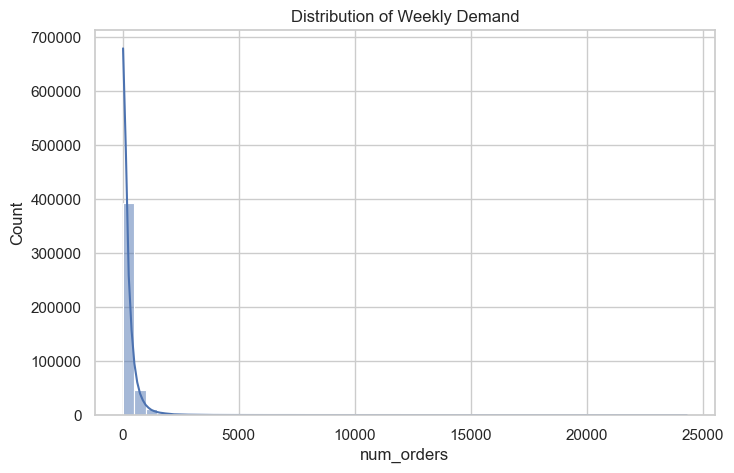

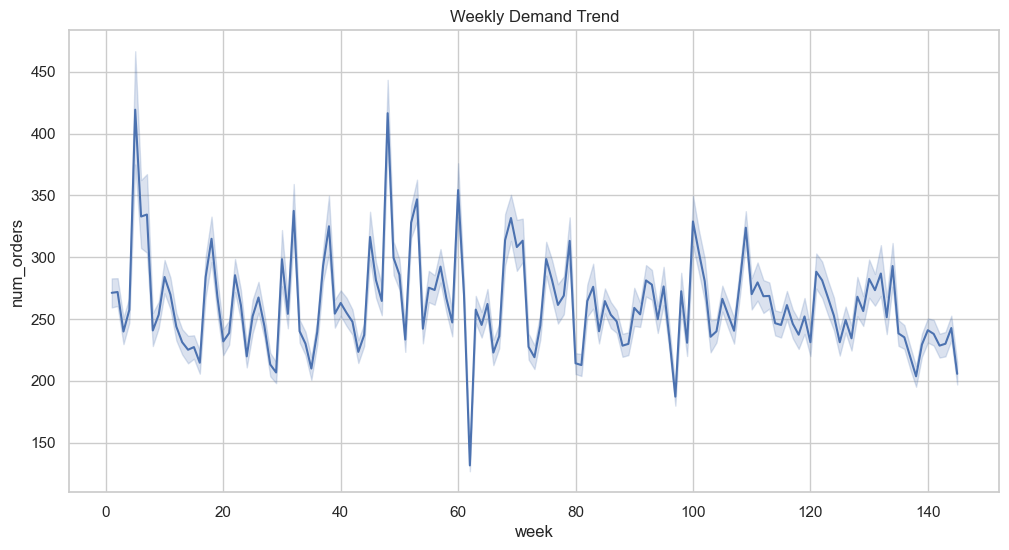

In [21]:

# Distribution of demand
plt.figure(figsize=(8,5))
sns.histplot(df['num_orders'], bins=50, kde=True)
plt.title("Distribution of Weekly Demand")
plt.show()

# Demand trend over weeks
plt.figure(figsize=(12,6))
sns.lineplot(x="week", y="num_orders", data=df)
plt.title("Weekly Demand Trend")
plt.show()


# Feature Selection

In [22]:
# Drop irrelevant columns
df_model = df.drop(["id", "num_orders"], axis=1)

# One-hot encode categorical variables
df_model = pd.get_dummies(df_model, drop_first=True)

# Features and target
X = df_model
y = df["num_orders"]


In [23]:
#Convert categorical variables

X = pd.get_dummies(X)

# Train Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


# Baseline model

In [25]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))


Linear Regression RMSE: 298.3252100346465
Linear Regression R²: 0.41653507609512663


# Random Forest model

In [27]:
# Train Random Forest with explicit parameters
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Evaluate performance
y_pred_rf = rf.predict(X_test)
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))


Random Forest RMSE: 143.11332362313888
Random Forest R²: 0.8657250565475993


# Cross-validation

In [28]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="r2")
print("Cross-validation R² scores:", cv_scores)
print("Average CV R²:", np.mean(cv_scores))


Cross-validation R² scores: [0.66967799 0.72765764 0.75273796 0.78601132 0.74223033]
Average CV R²: 0.7356630472267243


# Hyperparameter tuning

In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)


exception calling callback for <Future at 0x17a98d16a50 state=finished raised TerminatedWorkerError>
Traceback (most recent call last):
  File "C:\Users\USER\anaconda3\Lib\site-packages\joblib\externals\loky\_base.py", line 26, in _invoke_callbacks
    callback(self)
  File "C:\Users\USER\anaconda3\Lib\site-packages\joblib\parallel.py", line 385, in __call__
    self.parallel.dispatch_next()
  File "C:\Users\USER\anaconda3\Lib\site-packages\joblib\parallel.py", line 834, in dispatch_next
    if not self.dispatch_one_batch(self._original_iterator):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\USER\anaconda3\Lib\site-packages\joblib\parallel.py", line 901, in dispatch_one_batch
    self._dispatch(tasks)
  File "C:\Users\USER\anaconda3\Lib\site-packages\joblib\parallel.py", line 819, in _dispatch
    job = self._backend.apply_async(batch, callback=cb)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\USER\anaconda3\Lib\site-packages\j

# Model Performance

In [ ]:
# Evaluate model predictions
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("RMSE:", rmse)
print("R² Score:", r2)

# Interpretation:
# R² close to 1 means the model explains most of the variance in demand.
# RMSE shows the average prediction error in number of orders.


# Feature Importance

In [ ]:

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()


# 📉 Predicted vs Actual

In [ ]:

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Predicted vs Actual Demand")
plt.show()


# Feature importance

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
sns.barplot(x=importances[indices][:15], y=X.columns[indices][:15])
plt.title("Top 15 Feature Importances")
plt.show()


# Save trained model

In [ ]:
joblib.dump(rf, "food_demand_model.pkl")

# load and predict

In [ ]:
# Load model
model = joblib.load("food_demand_model.pkl")

# Predict on new data (example: first row of test set)
sample = X_test.iloc[0].values.reshape(1, -1)
print("Predicted demand:", model.predict(sample))
